In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

In [2]:
df = pd.read_excel("C:/Users/adria/OneDrive/Escritorio/Repaso Python Anlisis de datos/Analisis_Empleados.xlsx")
df

,id_empleado,edad,genero,departamento,sueldo_mensual,distancia_oficina_km,años_experiencia,nivel_satisfaccion,horas_extras_mes,riesgo_renuncia
0,1001,28,Masculino,IT,115000,12,4,2,32,1
1,1002,45,Femenino,Ventas,138000,45,18,4,10,0
2,1003,31,No Binario,Finanzas,92000,5,8,5,0,0
3,1004,24,Femenino,Marketing,45000,28,2,1,28,1
4,1005,52,Masculino,IT,142000,15,25,3,15,0
5,1006,39,Femenino,RRHH,88000,2,12,4,5,0
6,1007,27,Masculino,Ventas,62000,38,5,2,35,1
7,1008,48,No Binario,Finanzas,125000,10,20,5,0,0
8,1009,35,Femenino,IT,105000,22,10,3,20,0
9,1010,42,Masculino,Marketing,98000,18,15,2,12,0


In [ ]:
# Columnas nuevas - Humanizamos los numeros transformandolos en clasificaciones, facilitando la rapida interpretacion.

In [9]:
#clasificacion salario
condition=[
    df["sueldo_mensual"] >= 100000,
    df["sueldo_mensual"] >= 80000
]
choice = ("Alto","Medio")
df["clasificacion_salario"] = np.select(condition, choice, default = "Bajo")

#clasificacion distancia
condition = [
    df["distancia_oficina_km"] >= 25, 
    df["distancia_oficina_km"] >= 15
]
choice = ("Larga","Media")
df["clasificacion_distancia"] = np.select(condition,choice, default = "Corta")

#clasificacion antiguedad
condition = [
    df["años_experiencia"] >= 12,
    df["años_experiencia"] >= 8
]
choice = ("Alta", "Media")
df["nivel_antiguedad"] = np.select(condition,choice, default = "Baja")

#clasificacion satisfaccion
condition = [
    df["nivel_satisfaccion"] >= 4,
    df["nivel_satisfaccion"] == 3,
]
choice = ("Alta","Media")
df["clasificacion_satisfaccion"] = np.select(condition,choice,default="Baja")

#clasificacion horas extras
condition = [
    df["horas_extras_mes"] >= 25,
    df["horas_extras_mes"] >= 11
]
choice = ("Carga Alta","Carga Media")
df["carga_horas_extras"] = np.select(condition, choice, default="Carga Baja")
df

,id_empleado,edad,genero,departamento,sueldo_mensual,distancia_oficina_km,años_experiencia,nivel_satisfaccion,horas_extras_mes,riesgo_renuncia,clasificacion_salario,clasificacion_distancia,nivel_antiguedad,clasificacion_satisfaccion,carga_horas_extras
0,1001,28,Masculino,IT,115000,12,4,2,32,1,Alto,Corta,Baja,Baja,Carga Alta
1,1002,45,Femenino,Ventas,138000,45,18,4,10,0,Alto,Larga,Alta,Alta,Carga Baja
2,1003,31,No Binario,Finanzas,92000,5,8,5,0,0,Medio,Corta,Media,Alta,Carga Baja
3,1004,24,Femenino,Marketing,45000,28,2,1,28,1,Bajo,Larga,Baja,Baja,Carga Alta
4,1005,52,Masculino,IT,142000,15,25,3,15,0,Alto,Media,Alta,Media,Carga Media
5,1006,39,Femenino,RRHH,88000,2,12,4,5,0,Medio,Corta,Alta,Alta,Carga Baja
6,1007,27,Masculino,Ventas,62000,38,5,2,35,1,Bajo,Larga,Baja,Baja,Carga Alta
7,1008,48,No Binario,Finanzas,125000,10,20,5,0,0,Alto,Corta,Alta,Alta,Carga Baja
8,1009,35,Femenino,IT,105000,22,10,3,20,0,Alto,Media,Media,Media,Carga Media
9,1010,42,Masculino,Marketing,98000,18,15,2,12,0,Medio,Media,Alta,Baja,Carga Media


In [ ]:
# Tablas Pivot - Cruzaamos datos para sacar los primero insights

In [13]:
cm_azul = sns.light_palette("blue", as_cmap=True)

In [41]:

#Relacion salario - departamento
relacion_departamento_salario = df.pivot_table(
    values = "id_empleado",
    index = "departamento",
    columns = "clasificacion_salario",
    aggfunc = "count",
    fill_value = 0
)
# relacion satisfaccion por departamento
relacion_departamento_satisfaccion = df.pivot_table(
    values = "id_empleado",
    index = "departamento",
    columns = "clasificacion_satisfaccion",
    aggfunc = "count",
    fill_value = 0
)
# relacion antiguedad por departamento
relacion_departamento_nivel_antiguedad = df.pivot_table(
    values = "id_empleado",
    index = "departamento",
    columns = "nivel_antiguedad",
    aggfunc = "count",
    fill_value = 0
)

# Relacion entre departamento y horas extras
relacion_departamento_horas_extras = df.pivot_table(
    values = "id_empleado",
    index = "departamento",
    columns = "carga_horas_extras",
    aggfunc = "count",
    fill_value = 0
)
print("Relacion salario - departamento")
display (relacion_departamento_salario.style.background_gradient(cmap=cm_azul).format(precision=2).set_caption("Análisis de Salarios por Departamento"))

print("Relacion satisfaccion por departamento")
display (relacion_departamento_satisfaccion.style.background_gradient(cmap=cm_azul).format(precision=2).set_caption("Satisfacción por Departamento")
)

print("Relacion antiguedad por departamento")
display (relacion_departamento_nivel_antiguedad.style.background_gradient(cmap=cm_azul).format(precision=0).set_caption("Distribución de Antigüedad por Departamento"))

print("Relacion entre departamento y horas extras")
display (relacion_departamento_horas_extras.style.background_gradient(cmap=cm_azul).format(precision=0).set_caption("Distribución de horas extras por Departamento"))

Relacion salario - departamento


clasificacion_salario,Alto,Bajo,Medio
departamento,,,
Finanzas,1,0,1
IT,3,0,0
Marketing,0,1,1
RRHH,0,0,1
Ventas,1,1,0


Relacion satisfaccion por departamento


clasificacion_satisfaccion,Alta,Baja,Media
departamento,,,
Finanzas,2,0,0
IT,0,1,2
Marketing,0,2,0
RRHH,1,0,0
Ventas,1,1,0


Relacion antiguedad por departamento


nivel_antiguedad,Alta,Baja,Media
departamento,,,
Finanzas,1,0,1
IT,1,1,1
Marketing,1,1,0
RRHH,1,0,0
Ventas,1,1,0


Relacion entre departamento y horas extras


carga_horas_extras,Carga Alta,Carga Baja,Carga Media
departamento,,,
Finanzas,0,2,0
IT,1,0,2
Marketing,1,0,1
RRHH,0,1,0
Ventas,1,1,0


In [ ]:
# Analisis por departamento

In [57]:

relacion_departamento_h_extras_mes = df.groupby("departamento").agg(
    total_horas_extras_mes = ("horas_extras_mes","sum"),
    salario_promedio = ("sueldo_mensual","mean"),
    promedio_nivel_satisfaccion = ("nivel_satisfaccion","mean"),
    cantidad_empleados = ("id_empleado","count")
).sort_values(by = "total_horas_extras_mes", ascending = False).round(2)
relacion_departamento_h_extras_mes["%salario"] = (relacion_departamento_h_extras_mes["salario_promedio"] / 
                                                  relacion_departamento_h_extras_mes["salario_promedio"].sum() *100).round(2).astype(str) + "%"
Orden = [
"total_horas_extras_mes",
"salario_promedio",
"%salario",
"promedio_nivel_satisfaccion",
"cantidad_empleados"
]
relacion_departamento_h_extras_mes = relacion_departamento_h_extras_mes [Orden]
relacion_departamento_h_extras_mes


,total_horas_extras_mes,salario_promedio,%salario,promedio_nivel_satisfaccion,cantidad_empleados
departamento,,,,,
IT,67,120666.67,24.69%,2.67,3
Ventas,45,100000.00,20.46%,3.00,2
Marketing,40,71500.00,14.63%,1.50,2
RRHH,5,88000.00,18.01%,4.00,1
Finanzas,0,108500.00,22.2%,5.00,2


In [ ]:
# Aplicamos filtros para detectar empleados con altas probabilidades de renuncia

In [155]:
empleados_en_alerta = df[
    (df["clasificacion_satisfaccion"] == "Baja") & 
    (df["horas_extras_mes"] > 20) &
    (df["clasificacion_salario"] == "Bajo")
]
empleados_en_alerta 

,id_empleado,edad,genero,departamento,sueldo_mensual,distancia_oficina_km,años_experiencia,nivel_satisfaccion,horas_extras_mes,riesgo_renuncia,clasificacion_salario,clasificacion_distancia,nivel_antiguedad,clasificacion_satisfaccion,carga_horas_extras
3,1004,24,Femenino,Marketing,45000,28,2,1,28,1,Bajo,Larga,Baja,Baja,Carga Alta
6,1007,27,Masculino,Ventas,62000,38,5,2,35,1,Bajo,Larga,Baja,Baja,Carga Alta


In [201]:
# Detectamos con filtros el escenario ideal - [horas extras bajas] 
satisfaccion_alta = df[df["clasificacion_satisfaccion"] == "Alta"]
satisfaccion_alta

,id_empleado,edad,genero,departamento,sueldo_mensual,distancia_oficina_km,años_experiencia,nivel_satisfaccion,horas_extras_mes,riesgo_renuncia,clasificacion_salario,clasificacion_distancia,nivel_antiguedad,clasificacion_satisfaccion,carga_horas_extras
1,1002,45,Femenino,Ventas,138000,45,18,4,10,0,Alto,Larga,Alta,Alta,Carga Baja
2,1003,31,No Binario,Finanzas,92000,5,8,5,0,0,Medio,Corta,Media,Alta,Carga Baja
5,1006,39,Femenino,RRHH,88000,2,12,4,5,0,Medio,Corta,Alta,Alta,Carga Baja
7,1008,48,No Binario,Finanzas,125000,10,20,5,0,0,Alto,Corta,Alta,Alta,Carga Baja


In [203]:
#departamento comprometidos - satisfaccion baja
satisfaccion_baja = df[df["clasificacion_satisfaccion"] == "Baja"]
satisfaccion_baja

,id_empleado,edad,genero,departamento,sueldo_mensual,distancia_oficina_km,años_experiencia,nivel_satisfaccion,horas_extras_mes,riesgo_renuncia,clasificacion_salario,clasificacion_distancia,nivel_antiguedad,clasificacion_satisfaccion,carga_horas_extras
0,1001,28,Masculino,IT,115000,12,4,2,32,1,Alto,Corta,Baja,Baja,Carga Alta
3,1004,24,Femenino,Marketing,45000,28,2,1,28,1,Bajo,Larga,Baja,Baja,Carga Alta
6,1007,27,Masculino,Ventas,62000,38,5,2,35,1,Bajo,Larga,Baja,Baja,Carga Alta
9,1010,42,Masculino,Marketing,98000,18,15,2,12,0,Medio,Media,Alta,Baja,Carga Media


In [ ]:
### Conclusión Dual: Diagnóstico y Prevención
#Mientras que el análisis de riesgo identifica el "Burnout" en Marketing e IT, el filtro de satisfacción alta nos revela que la 
#estabilidad emocional del empleado está blindada por una carga horaria baja, actuando como un factor de retención más potente
#que el salario alto por sí solo.

In [ ]:
## Grafico de dispersion relacion sueldo - satisfaccion. El aumento del salario no influye en mayor satisfaccion 

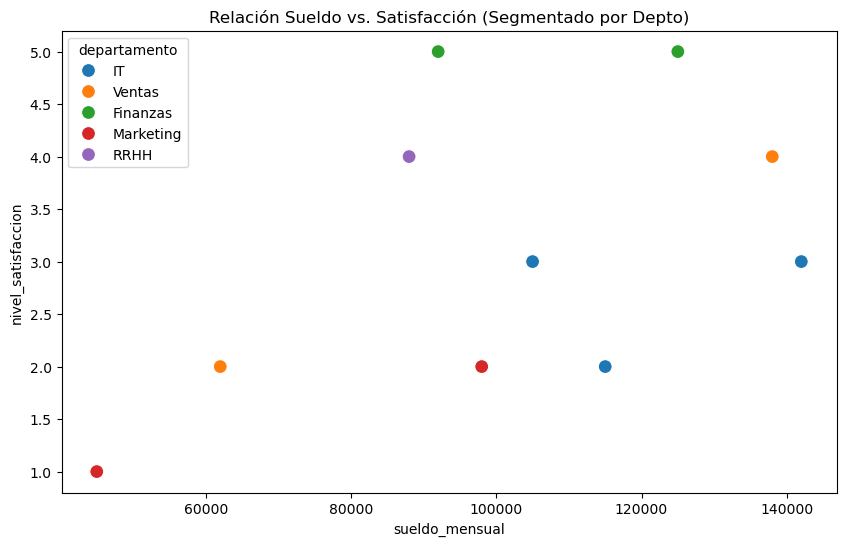

In [165]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='sueldo_mensual', y='nivel_satisfaccion', hue='departamento', s=100)
plt.title("Relación Sueldo vs. Satisfacción (Segmentado por Depto)")
plt.show()

In [ ]:
# Grafico de dispersion horas extras - satisfaccion. A mayor carga de hs estras menor satisfacccion.

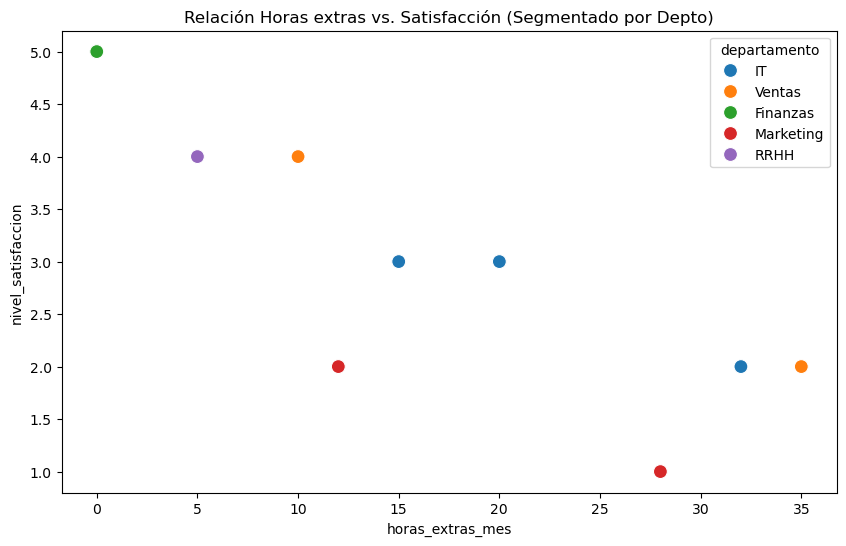

In [5]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='horas_extras_mes', y='nivel_satisfaccion', hue='departamento', s=100)
plt.title("Relación Horas extras vs. Satisfacción (Segmentado por Depto)")
plt.show()